# 03 - Exploratory Data Analysis

Explores demand, revenue, energy, waiting time, and duration patterns on the cleaned + feature-engineered dataset.

In [1]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv('../data/processed/ev_charging_features.csv')
df['date'] = pd.to_datetime(df['date'])
print(df.shape)
df.describe(include='all').T.head(15)

(84902, 39)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
session_id,84902,84902,SESS132793,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,84902,NaN,NaN,NaN,2024-07-09 09:22:55.600103,2024-01-01 00:00:00,2024-04-08 00:00:00,2024-07-14 00:00:00,2024-10-09 00:00:00,2024-12-31 00:00:00,NaN
start_time,84902,77035,2024-09-03 10:27:00,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
end_time,84902,84901,2024-12-29 16:53:00.000000000,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
station_id,84902,73,ST1011,3299,NaN,NaN,NaN,NaN,NaN,NaN,NaN
station_name,84902,73,Saket Ev Hub 1011,3299,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,84902,5,Mumbai,24574,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,84902,22,Viman Nagar,6818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,84902.0,NaN,NaN,NaN,19.491205,12.88951,18.43791,18.59275,19.11354,28.68725,4.742306
longitude,84902.0,NaN,NaN,NaN,75.185565,72.78945,72.94166,73.90334,77.26171,78.59594,2.156757


## A. Overall demand by hour
**What it shows:** total sessions per hour of day.
**What it means:** two peaks (morning + evening commute charging).
**Why it matters:** identifies when infrastructure is under the most pressure.

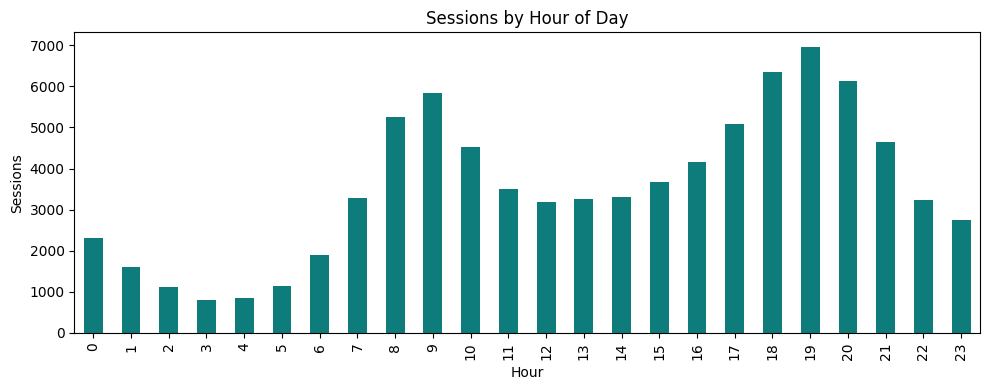

In [2]:
hourly = df.groupby('hour').size()
hourly.plot(kind='bar', figsize=(10,4), color='#0E7C7B', title='Sessions by Hour of Day')
plt.xlabel('Hour'); plt.ylabel('Sessions'); plt.tight_layout(); plt.show()

## B. Weekday vs weekend demand
**What it shows:** average sessions on weekdays vs weekend days.
**What it means:** if weekday demand is meaningfully higher, usage is commuter-driven.
**Why it matters:** informs whether pricing/staffing should differ by day type.

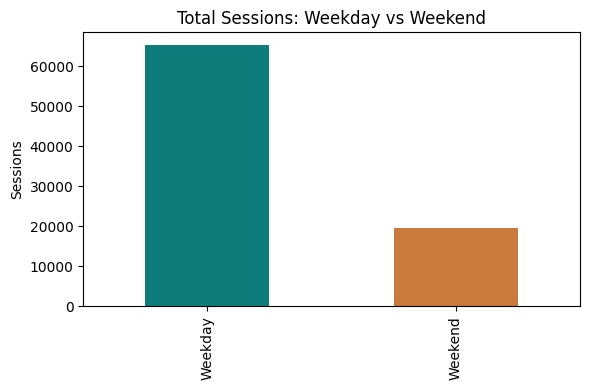

In [3]:
wk = df.groupby('is_weekend').size()
wk.index = ['Weekday','Weekend']
wk.plot(kind='bar', figsize=(6,4), color=['#0E7C7B','#C97A3D'], title='Total Sessions: Weekday vs Weekend')
plt.ylabel('Sessions'); plt.tight_layout(); plt.show()

## C. Monthly demand trend
**What it shows:** total sessions per month across the year.
**What it means:** reveals seasonality/growth trend.
**Why it matters:** helps plan capacity ahead of high-demand months.

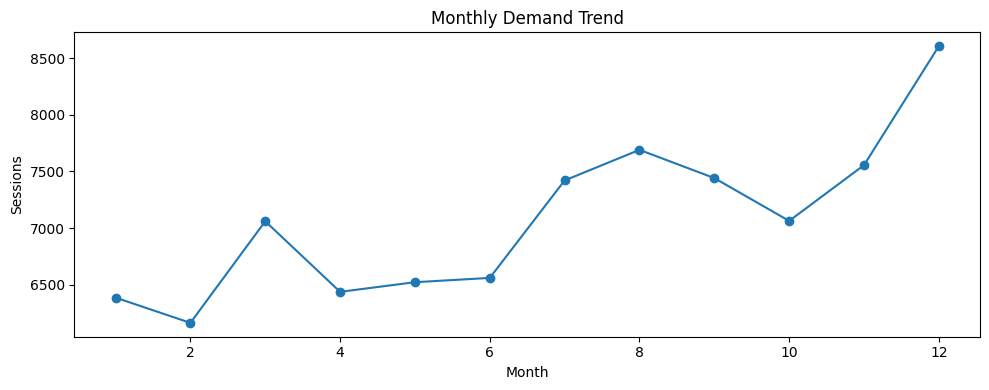

In [4]:
monthly = df.groupby('month').size()
monthly.plot(kind='line', marker='o', figsize=(10,4), title='Monthly Demand Trend')
plt.xlabel('Month'); plt.ylabel('Sessions'); plt.tight_layout(); plt.show()

## D. Vehicle-type behavior
**What it shows:** average energy consumed and duration per vehicle type.
**What it means:** larger vehicles draw more energy and charge longer.
**Why it matters:** vehicle mix shifts should inform charger-type investment.

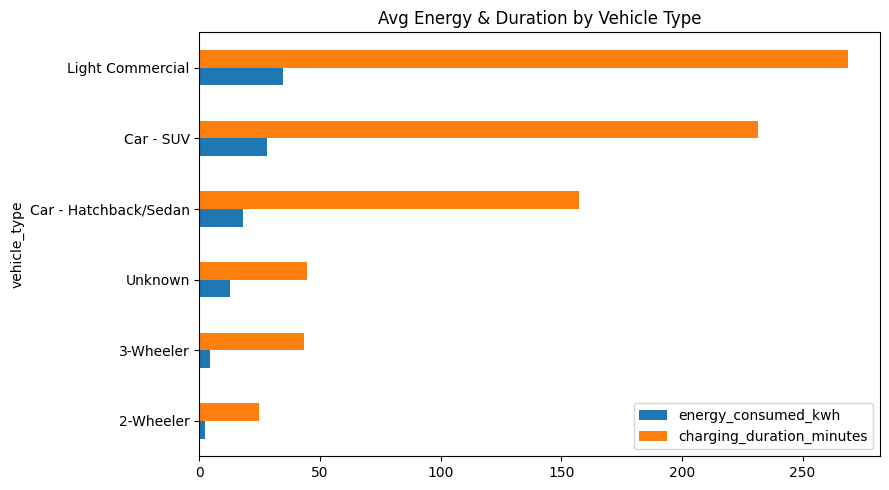

,energy_consumed_kwh,charging_duration_minutes
vehicle_type,,
2-Wheeler,2.198042,24.635408
3-Wheeler,4.509046,43.536694
Unknown,12.850000,44.700000
Car - Hatchback/Sedan,18.032543,157.354596
Car - SUV,27.972883,231.749738
Light Commercial,34.774136,268.686961


In [5]:
veh = df.groupby('vehicle_type')[['energy_consumed_kwh','charging_duration_minutes']].mean().sort_values('energy_consumed_kwh')
veh.plot(kind='barh', figsize=(9,5), title='Avg Energy & Duration by Vehicle Type')
plt.tight_layout(); plt.show()
veh

## E. Revenue and energy distribution
**What it shows:** distribution of revenue per session.
**What it means:** most sessions are low-value (2-wheelers/short top-ups) with a long tail of high-value sessions (SUVs/commercial).
**Why it matters:** average revenue alone can mislead pricing decisions -- the distribution matters.

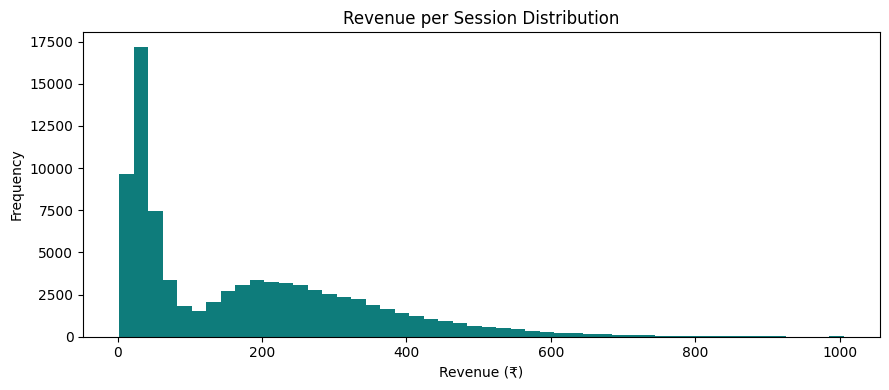

In [6]:
df['revenue'].plot(kind='hist', bins=50, figsize=(9,4), color='#0E7C7B', title='Revenue per Session Distribution')
plt.xlabel('Revenue (₹)'); plt.tight_layout(); plt.show()

## F. Waiting time vs charging duration
**What it shows:** relationship between how long a session takes and how long the wait was.
**What it means:** a weak/no direct correlation is expected -- wait time is driven by *station congestion*, not by the individual session's own duration.
**Why it matters:** confirms waiting time should be modeled at the station/hour level, not the session level -- which is exactly what the utilization analysis (notebook 04) does.

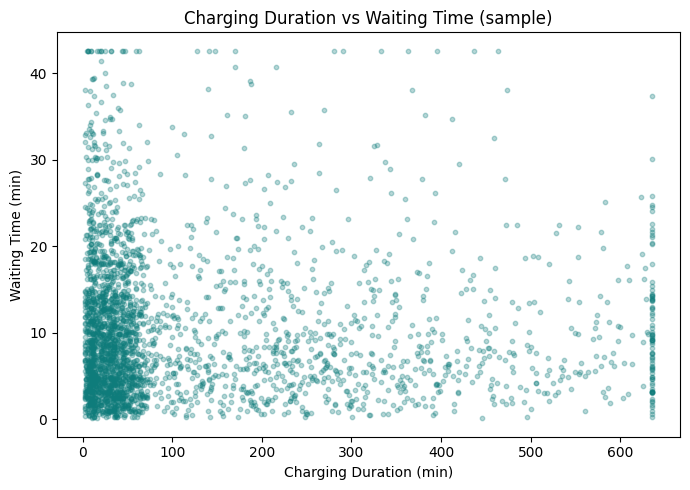

Correlation: -0.009


In [7]:
sample = df.sample(3000, random_state=1)
plt.figure(figsize=(7,5))
plt.scatter(sample['charging_duration_minutes'], sample['waiting_time_minutes'], alpha=0.3, s=10, color='#0E7C7B')
plt.xlabel('Charging Duration (min)'); plt.ylabel('Waiting Time (min)')
plt.title('Charging Duration vs Waiting Time (sample)'); plt.tight_layout(); plt.show()
print('Correlation:', round(df['charging_duration_minutes'].corr(df['waiting_time_minutes']), 3))